<a href="https://colab.research.google.com/github/askaasky/project_ml_uts/blob/main/pemodelan_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. IMPORT LIBRARY DAN LOADING DATA

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

data = pd.read_csv('diagnosed_cbc_data_v4.csv')

2. DATA UNDERSTANDING

In [7]:
print("===== 5 BARIS DATA AWAL =====")
print (data.head(5))

print("===== INFO DATA =====")
print(data.info())

print("===== DESKRIPSI DATA =====")
print(data.describe())

print("===== GAMBARAN UMUM DATASET =====")
print("Jumlah data:", data.shape)
print("\nJumlah tiap kelas:")
print(data['Diagnosis'].value_counts())

===== 5 BARIS DATA AWAL =====
    WBC  LYMp  NEUTp  LYMn  NEUTn   RBC  HGB    HCT   MCV   MCH  MCHC    PLT  \
0  10.0  43.2   50.1   4.3    5.0  2.77  7.3   24.2  87.7  26.3  30.1  189.0   
1  10.0  42.4   52.3   4.2    5.3  2.84  7.3   25.0  88.2  25.7  20.2  180.0   
2   7.2  30.7   60.7   2.2    4.4  3.97  9.0   30.5  77.0  22.6  29.5  148.0   
3   6.0  30.2   63.5   1.8    3.8  4.22  3.8   32.8  77.9  23.2  29.8  143.0   
4   4.2  39.1   53.7   1.6    2.3  3.93  0.4  316.0  80.6  23.9  29.7  236.0   

    PDW   PCT                      Diagnosis  
0  12.5  0.17  Normocytic hypochromic anemia  
1  12.5  0.16  Normocytic hypochromic anemia  
2  14.3  0.14         Iron deficiency anemia  
3  11.3  0.12         Iron deficiency anemia  
4  12.8  0.22  Normocytic hypochromic anemia  
===== INFO DATA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  ----- 

*3*. DATA PREPOCESING

In [8]:
# Load data baru
data = pd.read_csv('diagnosed_cbc_data_v4.csv')

# Salin data sebelum cleaning
data_before = data.copy()

# Cleaning
data_clean = data[(data['HGB'] > 0) &
                  (data['MCV'] > 0) &
                  (data['MCH'] > 0) &
                  (data['HCT'] > 0) &
                  (data['NEUTp'] >= 0) & (data['NEUTp'] <= 100) &
                  (data['LYMp'] >= 0) & (data['LYMp'] <= 100)]

print("Jumlah data sebelum:", len(data_before))
print("Jumlah data sesudah:", len(data_clean))

Jumlah data sebelum: 1281
Jumlah data sesudah: 1277


In [9]:
# pilih 3 kelas
kelas = [
    "Healthy",
    "Normocytic hypochromic anemia",
    "Normocytic normochromic anemia"
]

data_kelas = data_clean[data_clean["Diagnosis"].isin(kelas)]
data_kelas["Diagnosis"].value_counts()


,count
Diagnosis,
Healthy,335
Normocytic hypochromic anemia,278
Normocytic normochromic anemia,269


WBC          0
LYMp         0
NEUTp        0
LYMn         0
NEUTn        0
RBC          0
HGB          0
HCT          0
MCV          0
MCH          0
MCHC         0
PLT          0
PDW          0
PCT          0
Diagnosis    0
dtype: int64


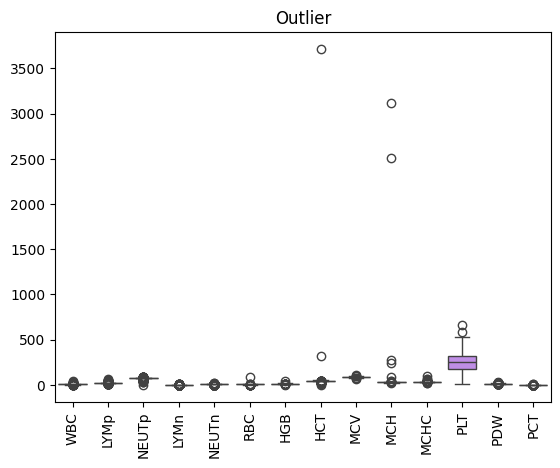

Jumlah duplikat: 35
Shape setelah hapus duplikat: (847, 15)


In [10]:
#Cek Missing Value
print(data_kelas.isnull().sum())

#Cek Outlier
sns.boxplot(data=data_kelas.drop('Diagnosis', axis=1))
plt.xticks(rotation=90)
plt.title("Outlier")
plt.show()

#Cek Data Duplikat
print("Jumlah duplikat:", data_kelas.duplicated().sum())
data_value = data_kelas.drop_duplicates()
print("Shape setelah hapus duplikat:", data_value.shape)

Jumlah data sebelum: 847
Jumlah data sesudah: 811


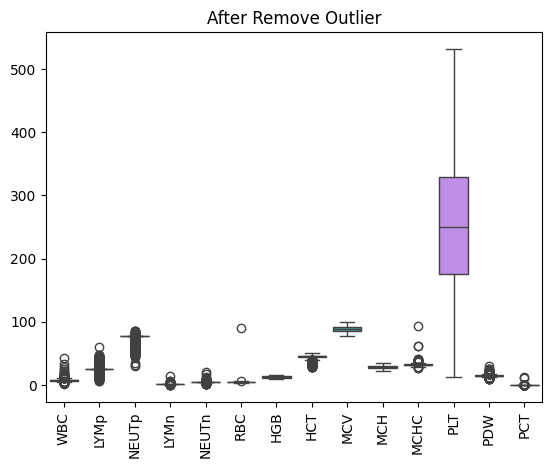

In [11]:
# Outlier removal
cols_outlier = ['HGB', 'MCV', 'MCH', 'PLT']
mask = np.ones(len(data_value), dtype=bool)
for col in cols_outlier:
    Q1 = data_value[col].quantile(0.25)
    Q3 = data_value[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    mask &= (data_value[col] >= lower) & (data_value[col] <= upper)

data_final = data_value[mask]

print("Jumlah data sebelum:", len(data_value))
print("Jumlah data sesudah:", len(data_final))

sns.boxplot(data=data_final.drop('Diagnosis', axis=1))
plt.xticks(rotation=90)
plt.title("After Remove Outlier")
plt.show()

In [12]:
# Encoding
le = LabelEncoder()
data_final = data_final.copy()
data_final["Diagnosis"] = le.fit_transform(data_final["Diagnosis"])
print(data_final["Diagnosis"].value_counts())
print(dict(zip(le.classes_, le.transform(le.classes_))))

Diagnosis
0    315
1    255
2    241
Name: count, dtype: int64
{'Healthy': np.int64(0), 'Normocytic hypochromic anemia': np.int64(1), 'Normocytic normochromic anemia': np.int64(2)}


4. EDA

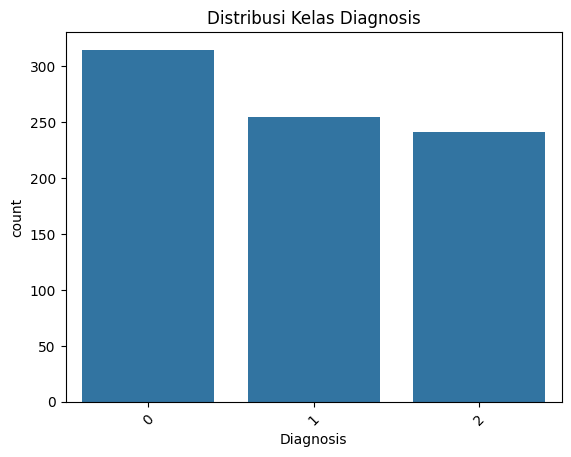

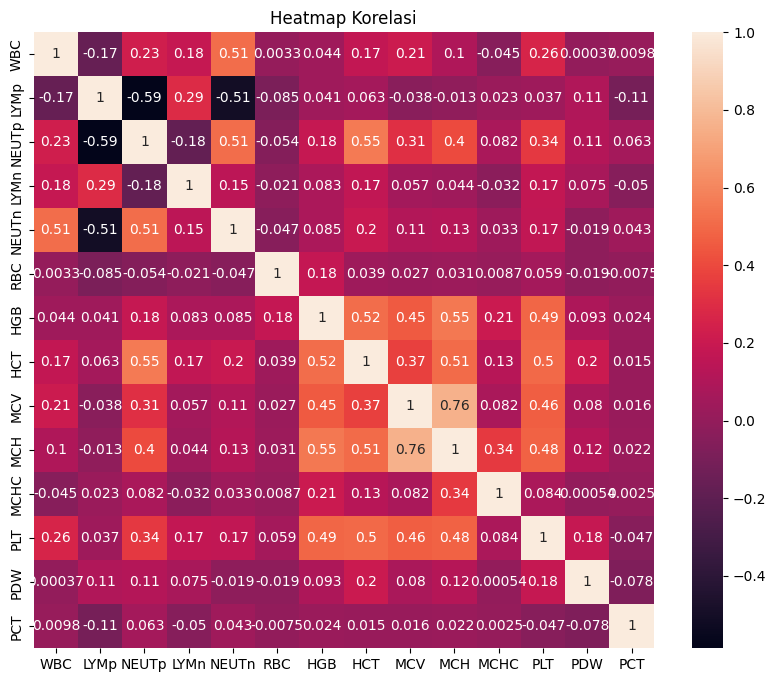

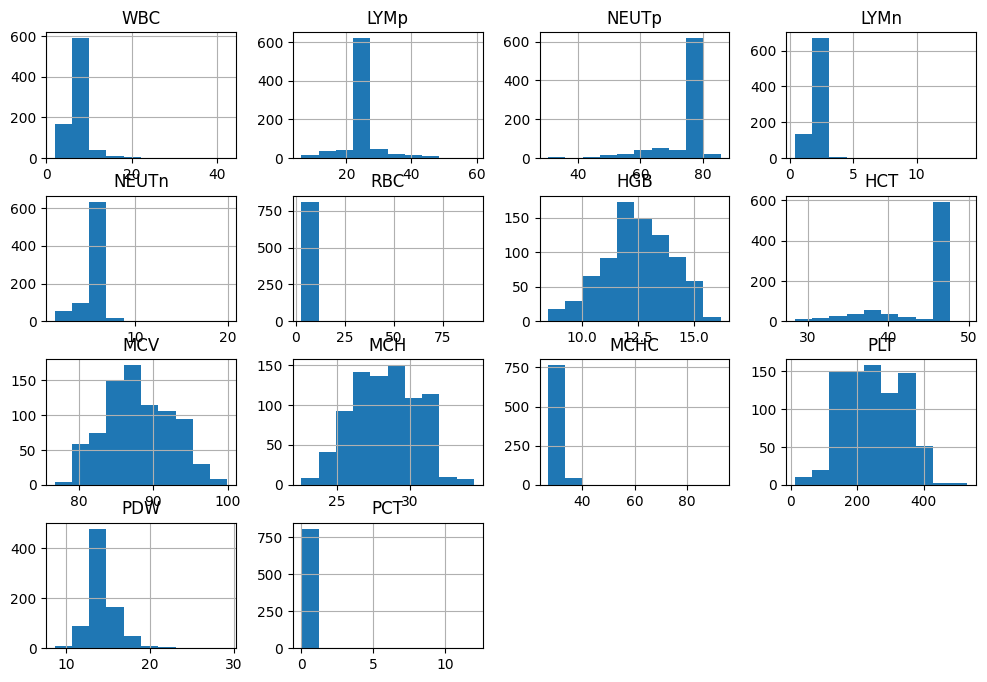

In [13]:
# Distribusi Kelas Diagnosis
plt.figure()
sns.countplot(x='Diagnosis', data=data_final)
plt.xticks(rotation=45)
plt.title("Distribusi Kelas Diagnosis")
plt.show()

# Heatmap Korelasi (Numeric features, exclude target)
plt.figure(figsize=(10,8))
sns.heatmap(data_final.drop('Diagnosis', axis=1).corr(), annot=True)
plt.title("Heatmap Korelasi")
plt.show()

# Histogram tiap fitur numerik
data_final.select_dtypes(include='float64').hist(figsize=(12,8))
plt.show()

5. DATA FEAUTURE & TARGET SELECTION

In [14]:
# X: fitur, y: target
X = data_final.drop('Diagnosis', axis=1)
y = data_final['Diagnosis']

6. DATA SPLITING, SCALING DAN EVALUASI MODEL

DATA SPLITING DAN SCALING (70 : 30)

In [15]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Scaling fitur numeric
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

EVALUASI MODEL (70 : 30)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=20, min_samples_split=50,
                       random_state=42)

Best Param : {'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 20, 'min_samples_split': 50}
Train Acc  : 0.9700176366843033
Test Acc   : 0.9795081967213115


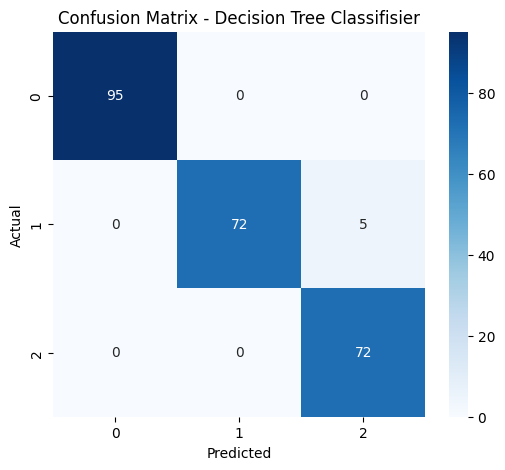

In [16]:
param_dt = {
    'max_depth': [1, 2],
    'min_samples_split': [50, 100],
    'min_samples_leaf': [20, 30],
    'criterion': ['gini'],
    'class_weight': [None]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    cv=5
)

from IPython.display import display
grid_dt.fit(X_train, y_train)
dt = grid_dt.best_estimator_

display(dt)

train_acc = dt.score(X_train, y_train)
test_acc = dt.score(X_test, y_test)

print("Best Param :", grid_dt.best_params_)
print("Train Acc  :", dt.score(X_train, y_train))
print("Test Acc   :", dt.score(X_test, y_test))

y_pred = dt.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree Classifisier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

results = []
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

results.append(["70:30", "Decision Tree", train_acc, test_acc, prec, rec, f1])

SVC(C=10, kernel='linear')

Best Param : {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}
Train Acc  : 0.9770723104056437
Test Acc   : 0.9344262295081968


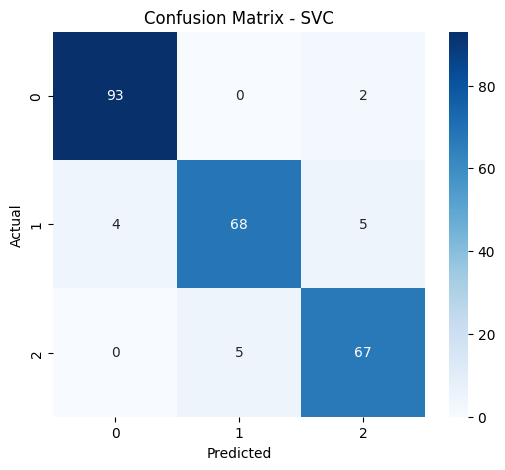

In [17]:
param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale'],
    'class_weight': [None]
}

grid_svm = GridSearchCV(
    SVC(),
    param_svm,
    cv=5
)

grid_svm.fit(X_train, y_train)
svm = grid_svm.best_estimator_

display(svm)

train_acc = svm.score(X_train, y_train)
test_acc = svm.score(X_test, y_test)

print("Best Param :", grid_svm.best_params_)
print("Train Acc  :", svm.score(X_train, y_train))
print("Test Acc   :", svm.score(X_test, y_test))

y_pred = svm.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

results.append(["70:30", "SVM", train_acc, test_acc, prec, rec, f1])

LogisticRegression(C=10, max_iter=1000)

Best Param : {'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Train Acc  : 0.9717813051146384
Test Acc   : 0.930327868852459


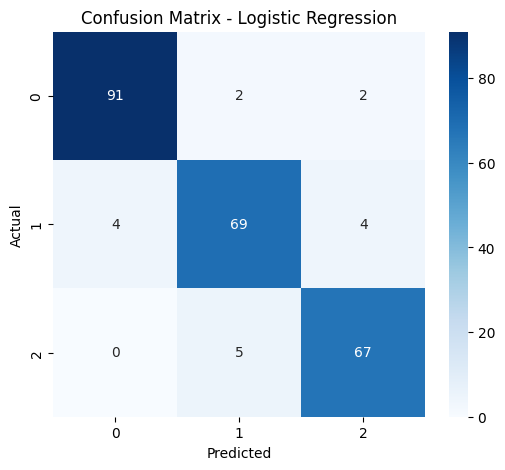

In [18]:
param_lr = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs'],
    'penalty': ['l2'],
    'class_weight': [None]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    cv=5
)

grid_lr.fit(X_train, y_train)
lr = grid_lr.best_estimator_

display(lr)

train_acc = lr.score(X_train, y_train)
test_acc = lr.score(X_test, y_test)

print("Best Param :", grid_lr.best_params_)
print("Train Acc  :", lr.score(X_train, y_train))
print("Test Acc   :", lr.score(X_test, y_test))

y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

results.append(["70:30", "Logistic Regression", train_acc, test_acc, prec, rec, f1])

DATA SPLITING DAN SCALING (80 : 20)

In [19]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling fitur numeric
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

EVALUASI MODEL (80 : 20)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=20, min_samples_split=50,
                       random_state=42)

Best Param : {'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 20, 'min_samples_split': 50}
Train Acc  : 0.9722222222222222
Test Acc   : 0.9754601226993865


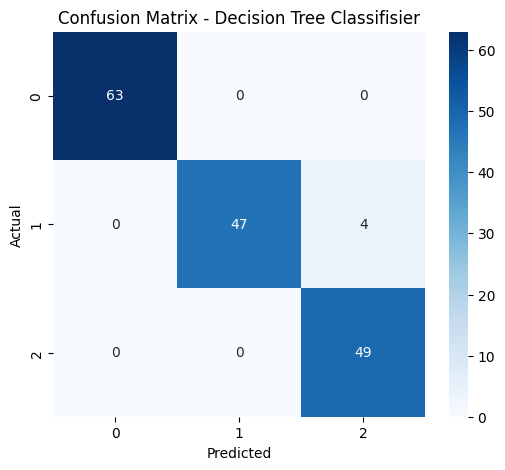

In [20]:
param_dt = {
    'max_depth': [1, 2],
    'min_samples_split': [50, 100],
    'min_samples_leaf': [20, 30],
    'criterion': ['gini'],
    'class_weight': [None]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    cv=5
)

from IPython.display import display
grid_dt.fit(X_train, y_train)
dt = grid_dt.best_estimator_

display(dt)

train_acc = dt.score(X_train, y_train)
test_acc = dt.score(X_test, y_test)

print("Best Param :", grid_dt.best_params_)
print("Train Acc  :", dt.score(X_train, y_train))
print("Test Acc   :", dt.score(X_test, y_test))

y_pred = dt.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree Classifisier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

results.append(["80:20", "Decision Tree", train_acc, test_acc, prec, rec, f1])

SVC(C=10, kernel='linear')

Best Param : {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}
Train Acc  : 0.9737654320987654
Test Acc   : 0.9263803680981595


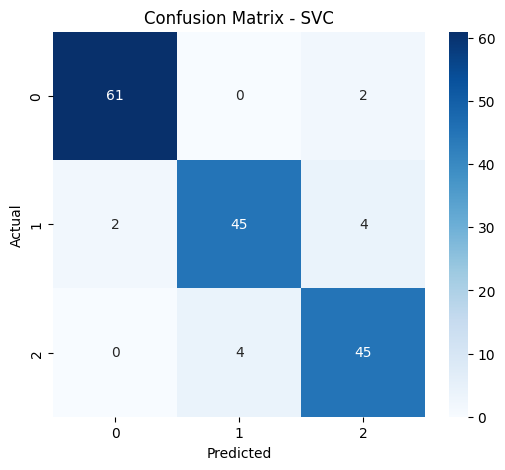

In [21]:
param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale'],
    'class_weight': [None]
}

grid_svm = GridSearchCV(
    SVC(),
    param_svm,
    cv=5
)

grid_svm.fit(X_train, y_train)
svm = grid_svm.best_estimator_

display(svm)

train_acc = svm.score(X_train, y_train)
test_acc = svm.score(X_test, y_test)

print("Best Param :", grid_svm.best_params_)
print("Train Acc  :", svm.score(X_train, y_train))
print("Test Acc   :", svm.score(X_test, y_test))

y_pred = svm.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

results.append(["80:20", "SVM", train_acc, test_acc, prec, rec, f1])

LogisticRegression(C=10, max_iter=1000)

Best Param : {'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Train Acc  : 0.9660493827160493
Test Acc   : 0.9141104294478528


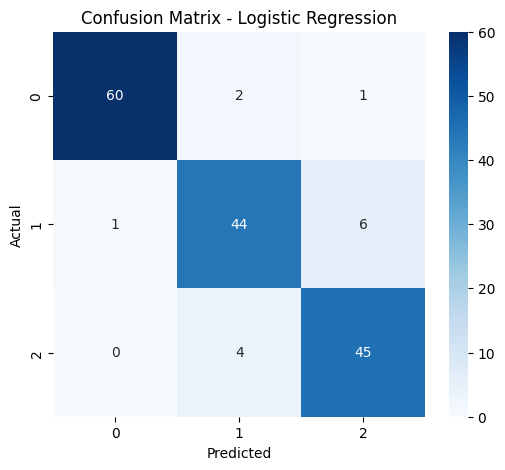

In [22]:
param_lr = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs'],
    'penalty': ['l2'],
    'class_weight': [None]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    cv=5
)

grid_lr.fit(X_train, y_train)
lr = grid_lr.best_estimator_

display(lr)

train_acc = lr.score(X_train, y_train)
test_acc = lr.score(X_test, y_test)

print("Best Param :", grid_lr.best_params_)
print("Train Acc  :", lr.score(X_train, y_train))
print("Test Acc   :", lr.score(X_test, y_test))

y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

results.append(["80:20", "Logistic Regression", train_acc, test_acc, prec, rec, f1])

DATA SPLITING DAN SCALING (90 : 10)

In [23]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

# Scaling fitur numeric
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

EVALUASI MODEL (90 : 10)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=20, min_samples_split=50,
                       random_state=42)

Best Param : {'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 20, 'min_samples_split': 50}
Train Acc  : 0.9739368998628258
Test Acc   : 0.9634146341463414


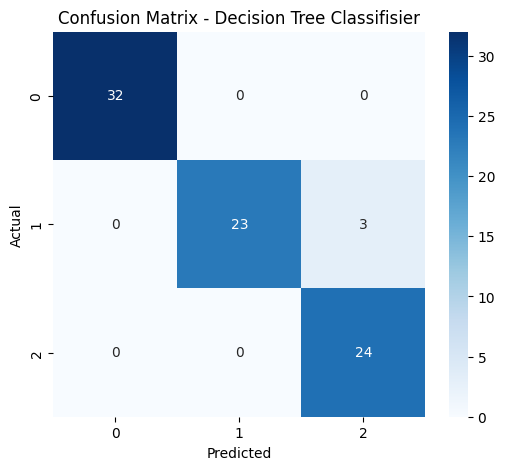

In [24]:
param_dt = {
    'max_depth': [1, 2],
    'min_samples_split': [50, 100],
    'min_samples_leaf': [20, 30],
    'criterion': ['gini'],
    'class_weight': [None]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    cv=5
)

from IPython.display import display
grid_dt.fit(X_train, y_train)
dt = grid_dt.best_estimator_

display(dt)

train_acc = dt.score(X_train, y_train)
test_acc = dt.score(X_test, y_test)

print("Best Param :", grid_dt.best_params_)
print("Train Acc  :", dt.score(X_train, y_train))
print("Test Acc   :", dt.score(X_test, y_test))

y_pred = dt.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree Classifisier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

results.append(["90:10", "Decision Tree", train_acc, test_acc, prec, rec, f1])

SVC(C=10, kernel='linear')

Best Param : {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}
Train Acc  : 0.9711934156378601
Test Acc   : 0.9146341463414634


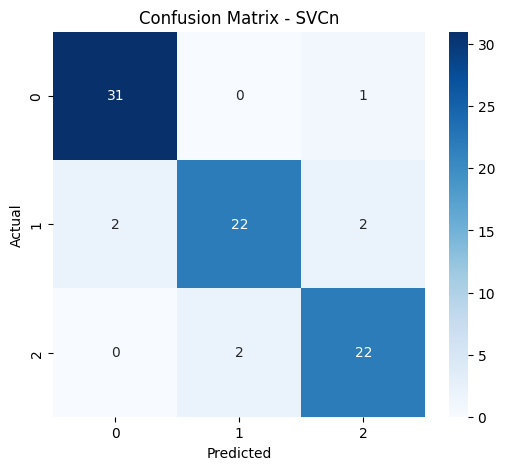

In [25]:
param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale'],
    'class_weight': [None]
}

grid_svm = GridSearchCV(
    SVC(),
    param_svm,
    cv=5
)

grid_svm.fit(X_train, y_train)
svm = grid_svm.best_estimator_

display(svm)

train_acc = svm.score(X_train, y_train)
test_acc = svm.score(X_test, y_test)

print("Best Param :", grid_svm.best_params_)
print("Train Acc  :", svm.score(X_train, y_train))
print("Test Acc   :", svm.score(X_test, y_test))

y_pred = svm.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVCn')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

results.append(["90:10", "SVM", train_acc, test_acc, prec, rec, f1])

LogisticRegression(C=10, max_iter=1000)

Best Param : {'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Train Acc  : 0.9602194787379973
Test Acc   : 0.9390243902439024


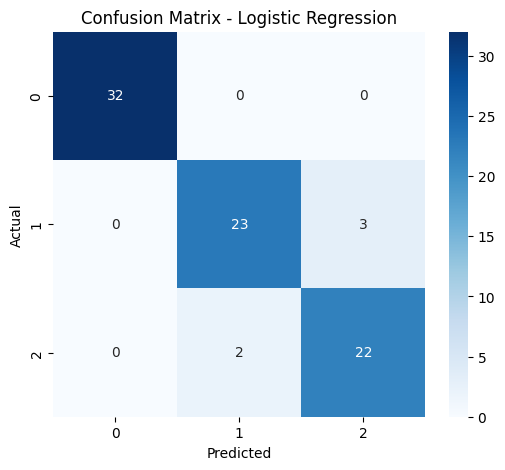

In [26]:
param_lr = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs'],
    'penalty': ['l2'],
    'class_weight': [None]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    cv=5
)

grid_lr.fit(X_train, y_train)
lr = grid_lr.best_estimator_

display(lr)

train_acc = lr.score(X_train, y_train)
test_acc = lr.score(X_test, y_test)

print("Best Param :", grid_lr.best_params_)
print("Train Acc  :", lr.score(X_train, y_train))
print("Test Acc   :", lr.score(X_test, y_test))

y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

results.append(["90:10", "Logistic Regression", train_acc, test_acc, prec, rec, f1])


===== HASIL MODEL =====
   Split                Model  Train Accuracy  Test Accuracy  Precision  \
0  70:30        Decision Tree        0.970018       0.979508   0.980839   
1  70:30                  SVM        0.977072       0.934426   0.934417   
2  70:30  Logistic Regression        0.971781       0.930328   0.930287   
3  80:20        Decision Tree        0.972222       0.975460   0.977312   
4  80:20                  SVM        0.973765       0.926380   0.926822   
5  80:20  Logistic Regression        0.966049       0.914110   0.915651   
6  90:10        Decision Tree        0.973937       0.963415   0.967480   
7  90:10                  SVM        0.971193       0.914634   0.914804   
8  90:10  Logistic Regression        0.960219       0.939024   0.939512   

     Recall  F1 Score  
0  0.979508  0.979508  
1  0.934426  0.934126  
2  0.930328  0.930282  
3  0.975460  0.975440  
4  0.926380  0.926380  
5  0.914110  0.914520  
6  0.963415  0.963371  
7  0.914634  0.914074  
8  0.939

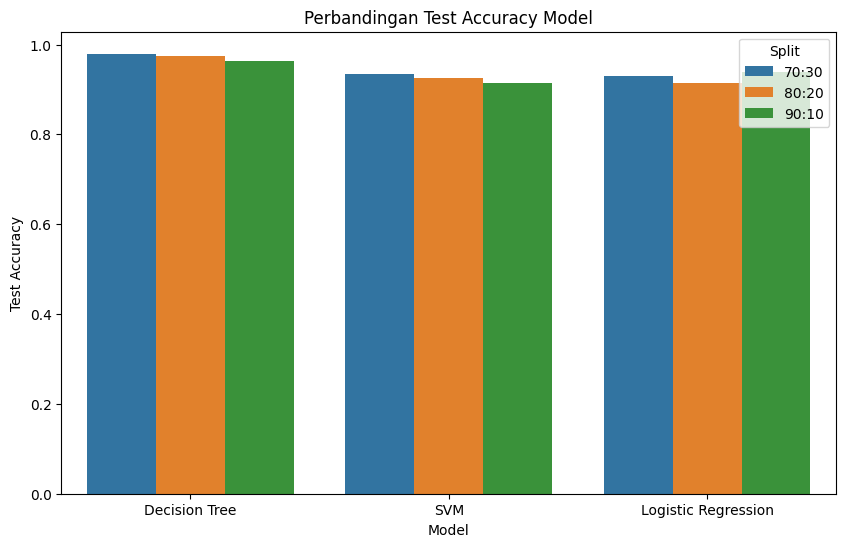

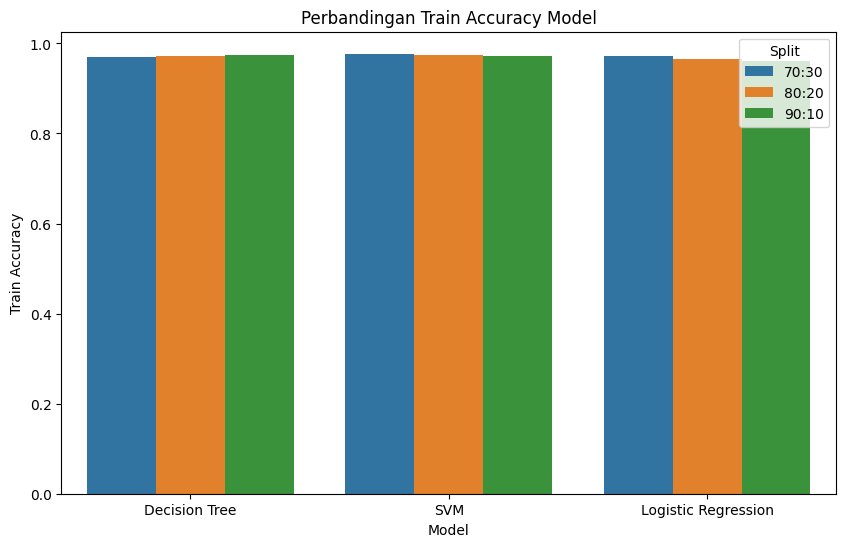

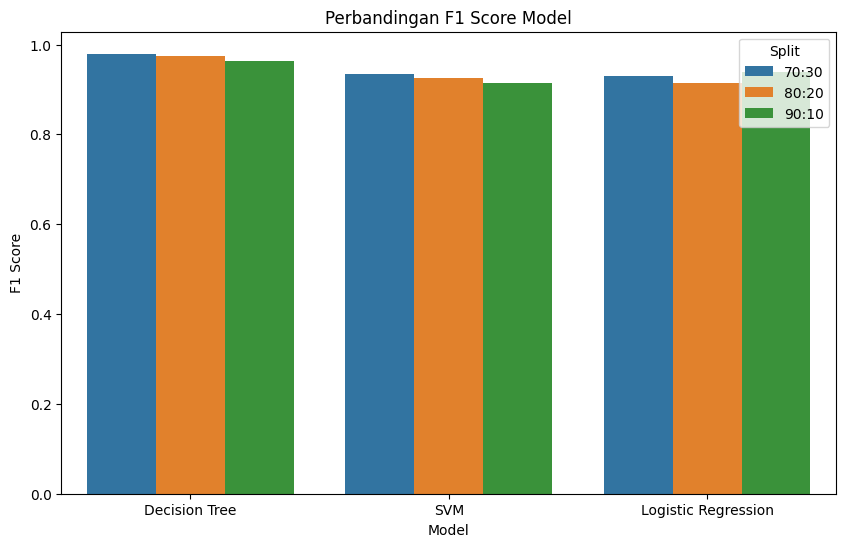

In [28]:
# DATAFRAME HASIL
results_df = pd.DataFrame(results, columns=[
    "Split",
    "Model",
    "Train Accuracy",
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])

print("\n===== HASIL MODEL =====")
print(results_df)

# RANKING MODEL
print("\n===== MODEL TERBAIK =====")
print(results_df.sort_values(by="Test Accuracy", ascending=False))

# VISUALISASI TEST ACCURACY
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="Model", y="Test Accuracy", hue="Split")
plt.title("Perbandingan Test Accuracy Model")
plt.show()

# VISUALISASI TRAIN ACCURACY
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="Model", y="Train Accuracy", hue="Split")
plt.title("Perbandingan Train Accuracy Model")
plt.show()

# VISUALISASI F1 SCORE
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="Model", y="F1 Score", hue="Split")
plt.title("Perbandingan F1 Score Model")
plt.show()

7. MODEL SAVING

In [32]:
import pickle

# simpan model (pakai SVM)
pickle.dump(svm, open("model.pkl", "wb"))

# simpan scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

# simpan label encoder
pickle.dump(le, open("label_encoder.pkl", "wb"))

print("Model, scaler, dan encoder berhasil disimpan")

Model, scaler, dan encoder berhasil disimpan


8. DOWNLOAD FILE MODEL

In [34]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

9. INFERENCE

In [39]:
# load
model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))
le = pickle.load(open("label_encoder.pkl", "rb"))

# bikin data baru dalam bentuk DataFrame
data_baru = pd.DataFrame([{
    "WBC": 10.0,
    "LYMp": 43.2,
    "NEUTp": 50.1,
    "LYMn": 4.3,
    "NEUTn": 5.0,
    "RBC": 2.77,
    "HGB": 7.3,
    "HCT": 24.2,
    "MCV": 87.7,
    "MCH": 26.3,
    "MCHC": 30.1,
    "PLT": 189.0,
    "PDW": 12.5,
    "PCT": 0.17
}])

# scaling
data_baru_scaled = scaler.transform(data_baru)

# prediksi
pred = model.predict(data_baru_scaled)

# decode
hasil = le.inverse_transform(pred)

print("Diagnosis:", hasil[0])

Diagnosis: Normocytic hypochromic anemia
